<a href="https://colab.research.google.com/github/Uday-1402/ML_Learn/blob/main/Understanding_your_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Understanding your data - Lecture 1

In [ ]:
# Asking basic questions | EDA {univariate analysis} | EDA {multivariate analysis} | Pandas Profiler Library

In [ ]:
import pandas as pd
df = pd.read_csv('/content/train.csv')

# How Big is the data?

In [ ]:
df.shape

(891, 12)

# What does data look like?

In [ ]:
df.head() # gives top 5 rows. (There may be bias.)
df.sample(5) # better : gives 5 random rows

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
807,808,0,3,"Pettersson, Miss. Ellen Natalia",female,18.0,0,0,347087,7.7750,NaN,S
248,249,1,1,"Beckwith, Mr. Richard Leonard",male,37.0,1,1,11751,52.5542,D35,S
787,788,0,3,"Rice, Master. George Hugh",male,8.0,4,1,382652,29.1250,NaN,Q
885,886,0,3,"Rice, Mrs. William (Margaret Norton)",female,39.0,0,5,382652,29.1250,NaN,Q
872,873,0,1,"Carlsson, Mr. Frans Olof",male,33.0,0,0,695,5.0000,B51 B53 B55,S


# What is the data type of cols?

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


# Are there missing values?

In [ ]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


# How does data look mathematically?

In [ ]:
df.describe() # Gives a high level statistical summary

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


# Are there duplicate values?

In [ ]:
df.duplicated().sum()

np.int64(0)

# Correlation between columns?

In [ ]:
df.select_dtypes(include='number').corr() # select_dtypes(include='number') takes only numerical columns in consideration else name column will cause problem because correlation can be there only for numerical values.

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
PassengerId,1.000000,-0.005007,-0.035144,0.036847,-0.057527,-0.001652,0.012658
Survived,-0.005007,1.000000,-0.338481,-0.077221,-0.035322,0.081629,0.257307
Pclass,-0.035144,-0.338481,1.000000,-0.369226,0.083081,0.018443,-0.549500
Age,0.036847,-0.077221,-0.369226,1.000000,-0.308247,-0.189119,0.096067
SibSp,-0.057527,-0.035322,0.083081,-0.308247,1.000000,0.414838,0.159651
Parch,-0.001652,0.081629,0.018443,-0.189119,0.414838,1.000000,0.216225
Fare,0.012658,0.257307,-0.549500,0.096067,0.159651,0.216225,1.000000


In [ ]:
df.select_dtypes(include='number').corr()['Survived']

,Survived
PassengerId,-0.005007
Survived,1.000000
Pclass,-0.338481
Age,-0.077221
SibSp,-0.035322
Parch,0.081629
Fare,0.257307


# EDA {Univariate Analysis : Analysis of a single variable/Analysis of a single Column.}

# Types of data :-
1. Numerical
2. Categorical

In [5]:
import pandas as pd
import seaborn as sns

In [6]:
df = pd.read_csv('/content/train.csv')

In [7]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


# 1. Categorical Data

(Name, Sex, SibSp, Parch, Ticket, Cabin, Embarked)

a. Countplot

<Axes: xlabel='Survived', ylabel='count'>

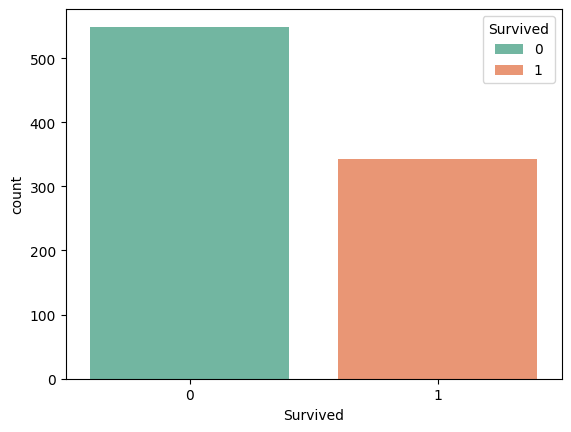

In [18]:
sns.countplot(x='Survived',data=df,hue='Survived', palette='Set2')
# df['Survived'].value_counts().plot(kind='bar')

<Axes: xlabel='Pclass', ylabel='count'>

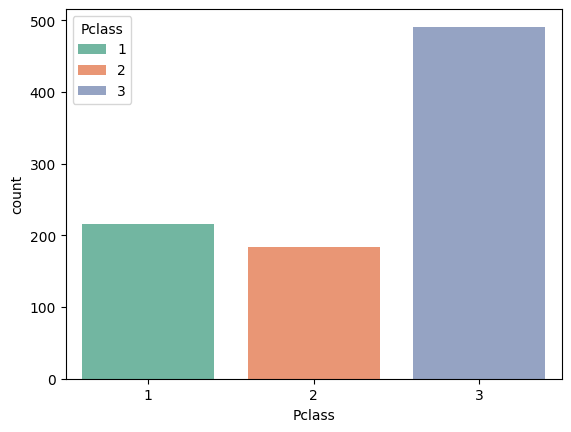

In [22]:
sns.countplot(x=df['Pclass'],hue=df['Pclass'],palette='Set2')


<Axes: xlabel='Sex', ylabel='count'>

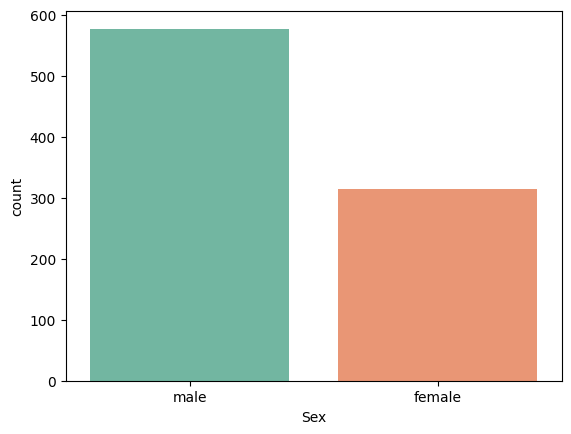

In [23]:
sns.countplot(x=df['Sex'],hue=df['Sex'],palette='Set2')


<Axes: xlabel='Embarked', ylabel='count'>

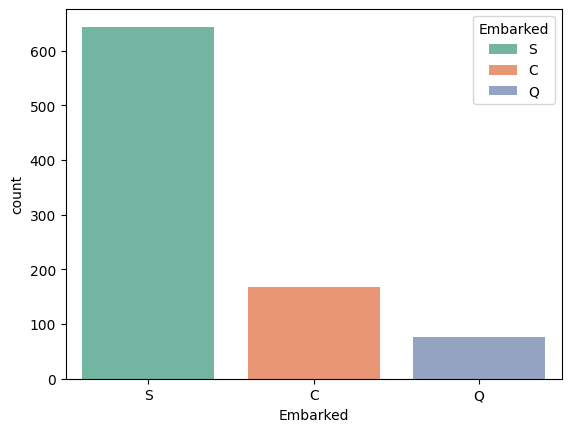

In [24]:
sns.countplot(x=df['Embarked'],hue=df['Embarked'],palette='Set2')


b. PieChart

<Axes: ylabel='count'>

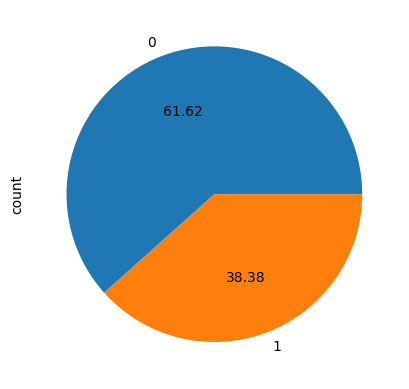

In [25]:
df['Survived'].value_counts().plot(kind='pie',autopct='%.2f')

<Axes: ylabel='count'>

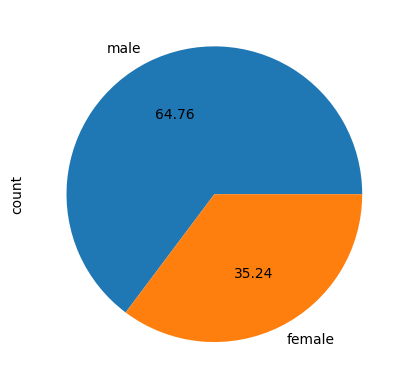

In [26]:
df['Sex'].value_counts().plot(kind='pie',autopct='%.2f')

<Axes: ylabel='count'>

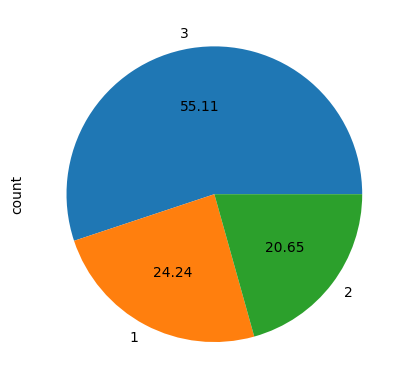

In [27]:
df['Pclass'].value_counts().plot(kind='pie',autopct='%.2f')

# 2. Numerical Data

a. Histogram

(array([100., 346., 188.,  69.,  11.]),
 array([ 0.42 , 16.336, 32.252, 48.168, 64.084, 80.   ]),
 <BarContainer object of 5 artists>)

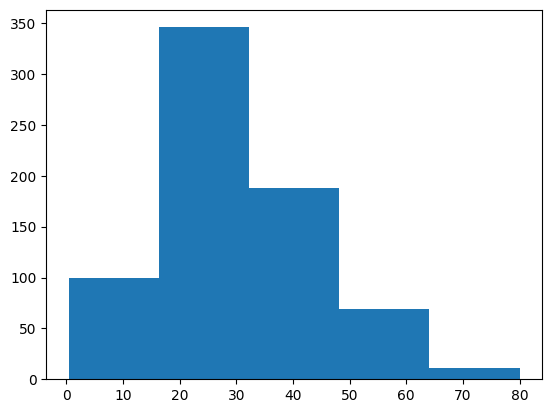

In [33]:
import matplotlib.pyplot as plt
plt.hist(df['Age'],bins=5)
# Gives the range. (No. of items in that range. Here no. of people in different age ranges.)

b. Distplot

/tmp/ipykernel_173/970433550.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Age'])


<Axes: xlabel='Age', ylabel='Density'>

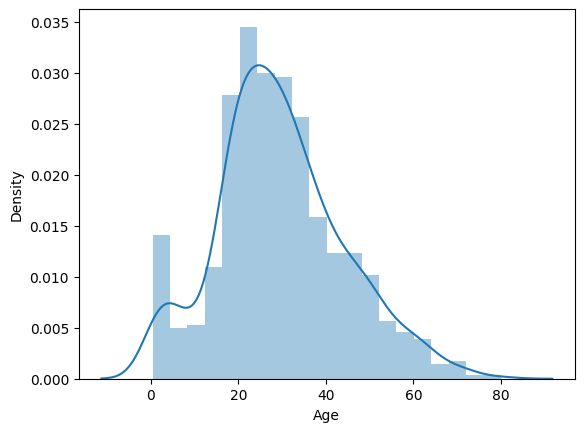

In [43]:
sns.distplot(df['Age'])
# Gives probability density function.
# Tells about skewness in data.(peak towards left or right not at the center.)

c. Boxplot

In [35]:
# Gives a 5 number summary.
# IQR = Interquartile Range = Q1 -> Q3
# Q1 = 25th percentile, Q3 = 75th percentile.
# Outliers : Minimum = Q1 - 1.5*IQR, Maximum = Q3 + 1.5*IQR

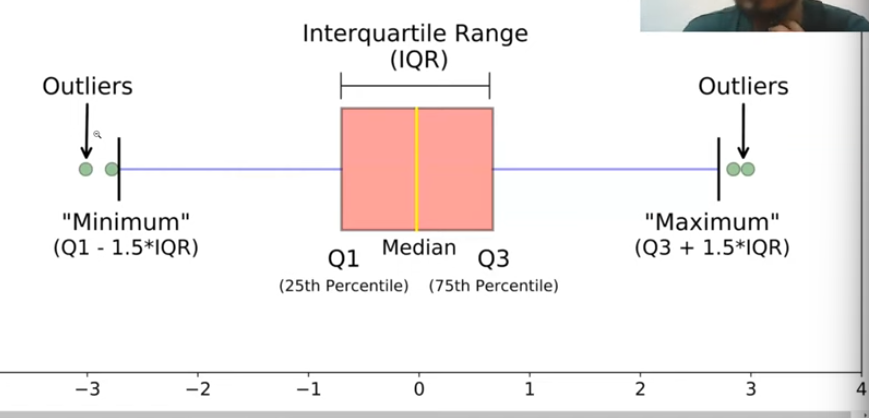

<Axes: xlabel='Fare'>

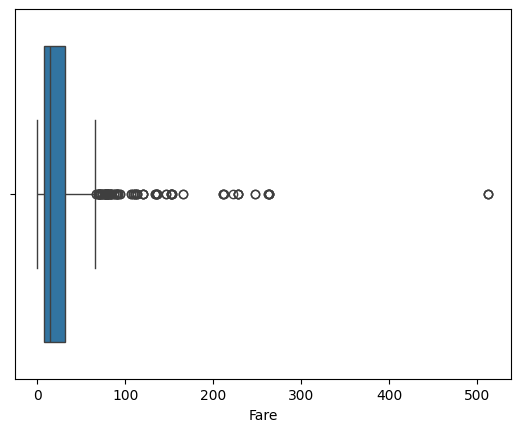

In [37]:
sns.boxplot(x=df['Fare'])

In [38]:
# Shifted towards left, 500 is an outlier should not depend on that.
# Boxplot helps identify noise in data/outliers in data.

<Axes: xlabel='Age'>

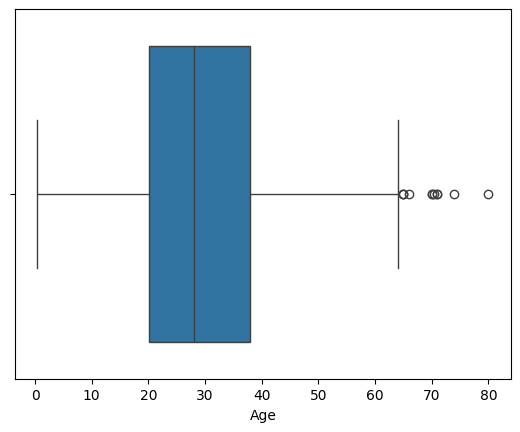

In [39]:
sns.boxplot(x=df['Age'])

In [40]:
df['Age'].min()

0.42

In [41]:
df['Age'].max()

80.0

In [42]:
df['Age'].mean()

np.float64(29.69911764705882)

In [45]:
# Skewness
# Positive => Towards Right
# Negative => Towards left
df['Age'].skew()

np.float64(0.38910778230082704)